# HESTON MODEL - STOCHASTIC VOLATILITY

https://www.codearmo.com/python-tutorial/heston-model-simulation-python

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats 

In [3]:
S0=100
r= 0.02
T=1
k=2.0
theta=0.04
sigma=0.5
rho=-0.7
v0=0.04
N=250
M=10000

Text(0.5, 1.0, 'Correlated Random Variables')

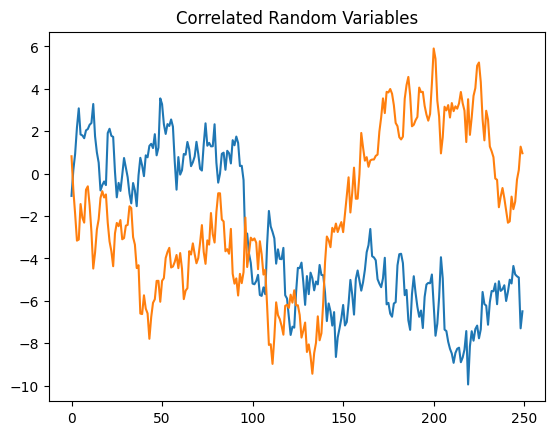

In [4]:
mu = np.array([0,0])
cov = np.array([[1, rho] , [rho , 1]])
W = np.random.multivariate_normal(mu, cov, size=N)

plt.plot(W.cumsum(axis=0));
plt.title('Correlated Random Variables')

In [ ]:
def generate_heston_paths(S, T, r, kappa, theta, v_0, rho, xi, 
                          steps, Npaths, return_vol=False):
    dt = T/steps
    size = (Npaths, steps)
    prices = np.zeros(size)
    sigs = np.zeros(size)
    S_t = S
    v_t = v_0
    for t in range(steps):
        WT = np.random.multivariate_normal(np.array([0,0]), 
                                           cov = np.array([[1,rho],
                                                          [rho,1]]), 
                                           size=Npaths) * np.sqrt(dt) 
        
        S_t = S_t*(np.exp( (r- 0.5*v_t)*dt+ np.sqrt(v_t) *WT[:,0] ) ) #USE EULERO!!!
        v_t = v_t + kappa*(theta-v_t)*dt + xi*np.sqrt(v_t)*WT[:,1]
        prices[:, t] = S_t
        sigs[:, t] = v_t
    
    if return_vol:
        return prices, sigs
    
    return prices

/var/folders/py/r8tccqns4cn3ck843phdlr700000gn/T/ipykernel_4296/211758368.py:15: RuntimeWarning: invalid value encountered in sqrt
  S_t = S_t*(np.exp( (r- 0.5*v_t)*dt+ np.sqrt(v_t) *WT[:,0] ) )
/var/folders/py/r8tccqns4cn3ck843phdlr700000gn/T/ipykernel_4296/211758368.py:16: RuntimeWarning: invalid value encountered in sqrt
  v_t = v_t + kappa*(theta-v_t)*dt + xi*np.sqrt(v_t)*WT[:,1]


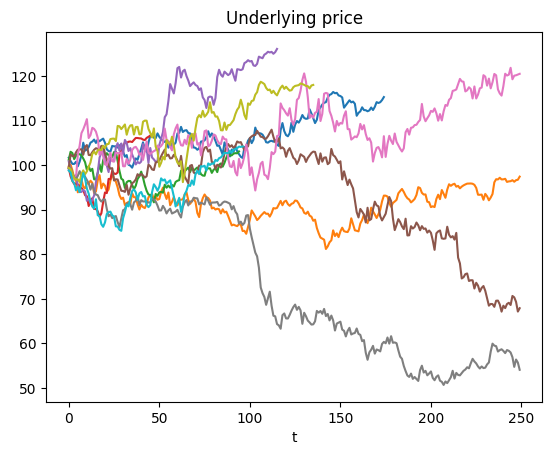

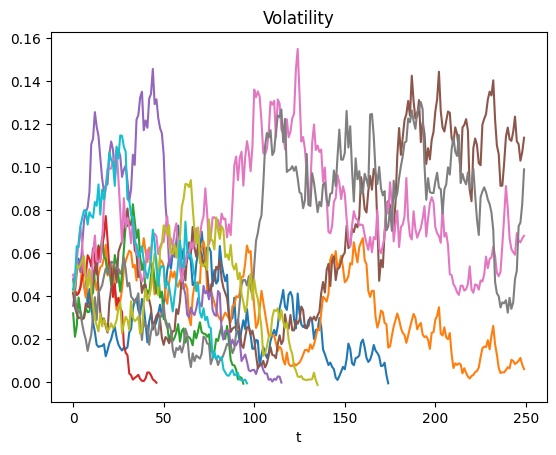

In [20]:
# VISUALIZE 10 PATHS
S, V = generate_heston_paths(S0, T, r, k, theta, v0, rho, sigma, N, 10, True)
plt.plot(S.T)
plt.title("Underlying price")
plt.xlabel("t")
plt.show()
plt.plot(V.T)
plt.title("Volatility")
plt.xlabel("t")
plt.show()

I have WARNINGS because i am not respecting Feller conditions (inside the sqrt i may have a negative value)

original code is reflecting (v=abs(...))

i should put a safety check inside sqrt(max(0,v))

In [ ]:
def generate_heston_paths_corrected(S, T, r, kappa, theta, v_0, rho, xi, 
                          steps, Npaths, return_vol=False):
    dt = T/steps
    size = (Npaths, steps)
    prices = np.zeros(size)
    sigs = np.zeros(size)
    S_t = S
    v_t = v_0
    for t in range(steps):
        WT = np.random.multivariate_normal(np.array([0,0]), 
                                           cov = np.array([[1,rho],
                                                          [rho,1]]), 
                                           size=Npaths) * np.sqrt(dt) 
        
        S_t = S_t + r * S_t * dt + np.sqrt(np.maximum(v_t, 0)) * S_t * WT[:, 0]     #THIS IS EULERO, BEFORE IT WAS WITH CLOSED FORM
        v_t = v_t + kappa*(theta-v_t)*dt + xi*np.sqrt(np.max(v_t,0))*WT[:,1]
        prices[:, t] = S_t
        sigs[:, t] = v_t
    
    if return_vol:
        return prices, sigs
    
    return prices

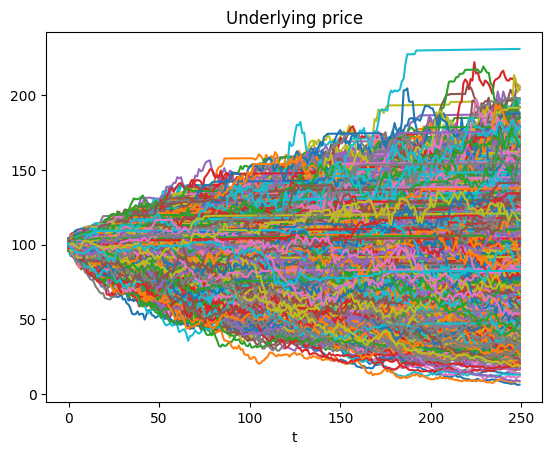

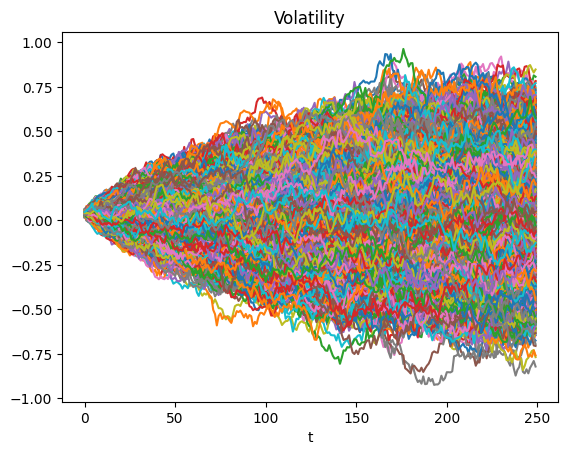

Text(0, 0.5, 'counts')

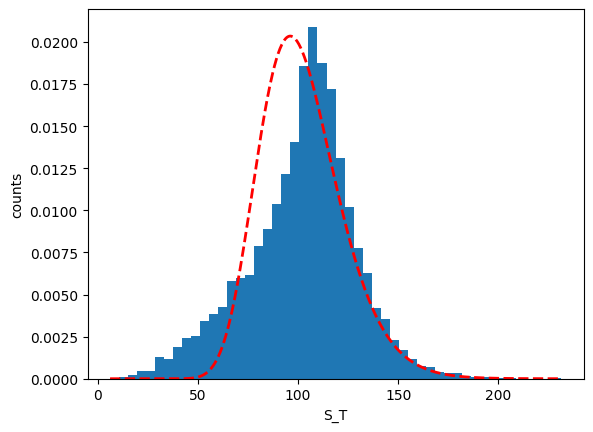

In [47]:
S, V = generate_heston_paths_corrected(S0, T, r, k, theta, v0, rho, sigma, N, M, True)
plt.plot(S.T)
plt.title("Underlying price")
plt.xlabel("t")
plt.show()
plt.plot(V.T)
plt.title("Volatility")
plt.xlabel("t")
plt.show()

S_T=S[:,-1]
np.shape(S_T)
x = np.linspace(np.min(S_T), np.max(S_T), 500)
plt.hist(S_T, 50, density=True)
# --- Black–Scholes parameters ---

sigma_bs = np.sqrt(theta)   # proxy volatility

mu = np.log(S0) + (r - 0.5 * sigma_bs**2) * T

s = sigma_bs * np.sqrt(T)

# BS lognormal density

pdf_bs = scipy.stats.lognorm.pdf(x, s=s, scale=np.exp(mu))

plt.plot(x, pdf_bs, 'r--', linewidth=2, label="Black–Scholes")


plt.xlabel("S_T")
plt.ylabel("counts")

In [ ]:
mean=np.mean(S_T)
variance=np.var(S_T)
skewness=
kurtosis

In [61]:
def EurCall(t,T,r,sigma,x,K):
    from scipy.stats import norm
    d1 = (np.log(x/K)+(r+sigma**2/2)*(T-t))/(sigma*np.sqrt(T-t))
    d2 = (np.log(x/K)+(r-sigma**2/2)*(T-t))/(sigma*np.sqrt(T-t))
    premium = x*norm.cdf(d1)-K*np.exp(-r*(T-t))*norm.cdf(d2)
    return premium

In [62]:
K=100

HestonCall=np.mean(np.exp(-r*T)*np.maximum(0, S_T-K))
BSCall=EurCall(0, T, r, sigma_bs, S0, K)

print(HestonCall, BSCall)

11.026649478479753 8.916037278572539
